# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [27]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import keras.applications as ka
import keras

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import StratifiedKFold

## Task 1
Implement the my_team()function 

In [ ]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [
        ("12422258", "Arran", "Abraham"),
        ("11772891", "Liam", "Nguyen"),
        ("12412392", "Phat", "Nguyen")
    ]

In [31]:
my_team()

[('12422258', 'Arran', 'Abraham'),
 ('11772891', 'Liam', 'Nguyen'),
 ('12412392', 'Phat', 'Nguyenh')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [32]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.
    '''

    X = []
    Y = []

    class_names = sorted(os.listdir(path))

    for label in class_names:
        class_dir = os.path.join(path, label)

        if not os.path.isdir(class_dir):
            continue

        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)

            try:
                img = keras.utils.load_img(file_path, target_size=(224, 224))
                x = keras.utils.img_to_array(img) / 255.0

                X.append(x)
                Y.append(label)

            except Exception:
                pass

    X = np.stack(X)
    Y = np.array(Y)

    dataset = (X, Y) 
    return dataset

In [33]:
dataset = load_data("small_flower_dataset")

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [34]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    Insert a more detailed description here.
    

    """

    # Convert inputs into NumPy arrays for easier indexing and slicing
    X = np.array(X)
    Y = np.array(Y)

    # Prepare empty lists to store final splits
    train_X, train_Y = [], []
    eval_X, eval_Y = [], []
    test_X, test_Y = [], []


    # encode string labels to integers
    classes = np.unique(Y)
    label_map = {c: i for i, c in enumerate(classes)}
    Y = np.array([label_map[y] for y in Y])

    # Find all unique class labels (e.g., daisy, rose, etc.)
    classes = np.unique(Y)

    # Loop through each class separately (this ensures balanced splitting)
    for c in classes:

        # Get indices of all samples belonging to class c
        idx = np.where(Y == c)[0]

        # Shuffle indices if randomization is enabled
        if randomize:
            np.random.shuffle(idx)

        # Select all X and Y samples for this class
        class_X = X[idx]
        class_Y = Y[idx]

        # Number of samples in this class
        n = len(class_X)

        # Compute where to split training data
        train_end = int(n * train_fraction)

        # Training portion for this class
        X_train_c = class_X[:train_end]
        Y_train_c = class_Y[:train_end]

        # Remaining data after training split
        remaining_X = class_X[train_end:]
        remaining_Y = class_Y[train_end:]

        # If evaluation set is required, split remaining into eval and test
        if eval_set:
            mid = len(remaining_X) // 2  # half for eval, half for test

            # Evaluation (validation) split
            X_eval_c = remaining_X[:mid]
            Y_eval_c = remaining_Y[:mid]

            # Test split
            X_test_c = remaining_X[mid:]
            Y_test_c = remaining_Y[mid:]

            # Add class data into global eval set
            eval_X.extend(X_eval_c)
            eval_Y.extend(Y_eval_c)

            # Add class data into global test set
            test_X.extend(X_test_c)
            test_Y.extend(Y_test_c)

        else:
            # If no eval set, all remaining goes to test set
            test_X.extend(remaining_X)
            test_Y.extend(remaining_Y)

        # Add class training data into global training set
        train_X.extend(X_train_c)
        train_Y.extend(Y_train_c)

    # Convert final lists back into NumPy arrays
    train_set = (np.array(train_X), np.array(train_Y))

    # Only create eval set if requested
    if eval_set:
        eval_set_out = (np.array(eval_X), np.array(eval_Y))
    else:
        eval_set_out = None

    # Test set is always returned
    test_set = (np.array(test_X), np.array(test_Y))

    return train_set, eval_set_out, test_set

In [35]:
X, Y = dataset
train_set, eval_set, test_set = split_data(X, Y, 0.7, randomize=True, eval_set=True)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

Insert details here.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [36]:
def load_model():
    '''
    Load in a model using the tf.keras.applications model and return it.
    Returns:
        model : keras.Model
                MobileNetV2 model without the top classification layer,
                pretrained on ImageNet.
    '''
    model = ka.MobileNetV2(
        input_shape=(224, 224, 3),   # expected image size
        include_top=False,           # remove final classification layer
        weights="imagenet"           # use pretrained ImageNet weights
    )

    return model    

In [37]:
model = load_model()

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.


In [38]:
model_new = keras.Sequential([
    model,
    keras.layers.GlobalAveragePooling2D(),  # converts feature maps → vector
    keras.layers.Dense(5, activation="softmax")  # 5 classes output
])



## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [39]:
def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    learning_rate, momentum, nesterov = parameters

    # Unpack data
    X_train, Y_train = train_set
    X_eval, Y_eval = eval_set

    # Add classification head for 5 classes
    x = keras.layers.GlobalAveragePooling2D()(model.output)
    output = keras.layers.Dense(5, activation="softmax")(x)

    model = keras.Model(inputs=model.input, outputs=output)

    # Freeze base model layers (important for transfer learning)
    for layer in model.layers[:-1]:
        layer.trainable = False

    # Define SGD optimizer
    optimizer = keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train model
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_eval, Y_eval),
        epochs=10,
        batch_size=32,
        shuffle=True
    )
    
    return model, history

In [40]:
model , history= transfer_learning(train_set, eval_set,model, parameters=(0.01, 0.0, False))

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.4414 - loss: 1.3259 - val_accuracy: 0.6533 - val_loss: 0.8988
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.7314 - loss: 0.8075 - val_accuracy: 0.7800 - val_loss: 0.6405
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8143 - loss: 0.6346 - val_accuracy: 0.8000 - val_loss: 0.5441
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.8386 - loss: 0.5473 - val_accuracy: 0.8400 - val_loss: 0.4866
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8600 - loss: 0.4882 - val_accuracy: 0.8400 - val_loss: 0.4486
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.8771 - loss: 0.4410 - val_accuracy: 0.8533 - val_loss: 0.4193
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.8843 - loss: 0.4059 - val_accuracy: 0.8600 - val_loss: 0.3986
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.8929 - loss: 0.3765 - val_accuracy: 0.

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

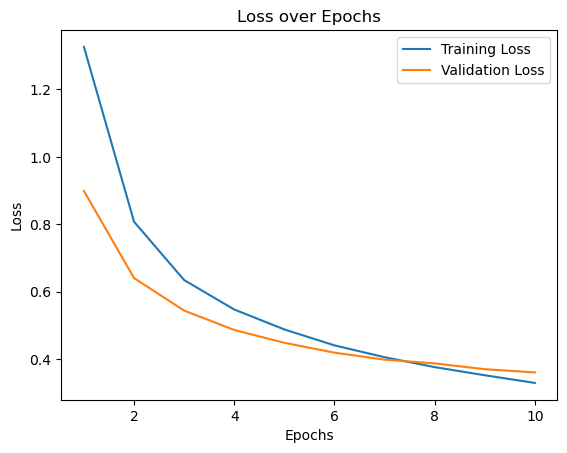

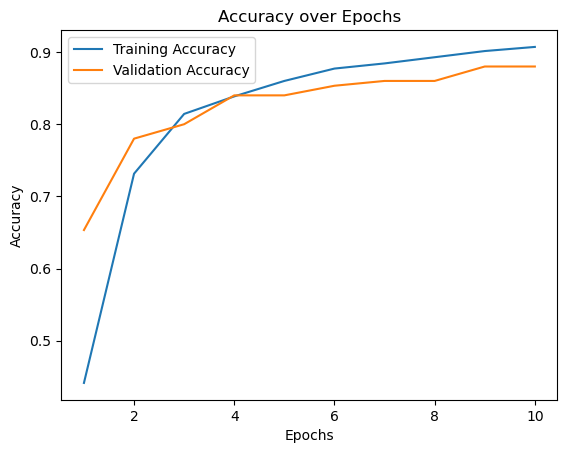

In [41]:
import matplotlib.pyplot as plt

def plot_training(history):
    # Extract values from training history
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    epochs = range(1, len(loss) + 1)

    # Plot loss
    plt.figure()
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title("Loss over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    
plot_training(history)

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

Training model with learning rate = 0.1
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.5743 - loss: 1.9981 - val_accuracy: 0.7267 - val_loss: 1.0605
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8500 - loss: 0.4453 - val_accuracy: 0.8533 - val_loss: 0.5023
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9114 - loss: 0.2670 - val_accuracy: 0.8133 - val_loss: 0.4535
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9400 - loss: 0.1758 - val_accuracy: 0.8467 - val_loss: 0.3606
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9729 - loss: 0.1171 - val_accuracy: 0.8733 - val_loss: 0.3156
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9843 - loss: 0.0891 - val_accuracy: 0.8800 - val_loss: 0.3164
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9957 - loss: 0.0714 - val_accuracy: 0.9000 - val_loss: 0.3152
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 

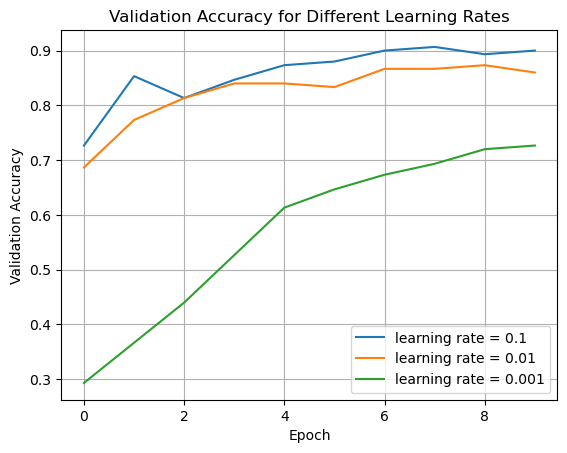

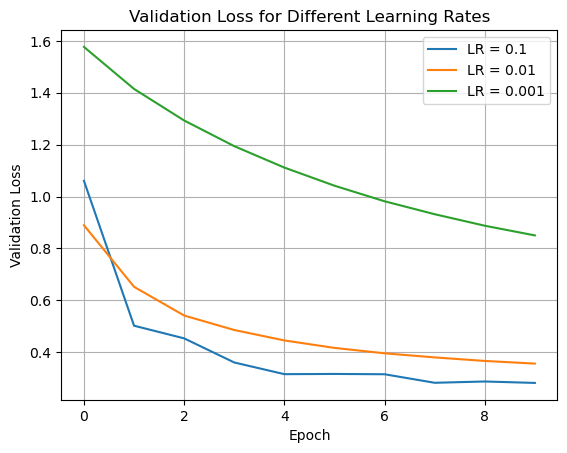


Final Results:
Learning Rate | Train Accuracy | Val Accuracy | Train Loss | Val Loss
0.1           | 1.0000    | 0.9000  | 0.0449     | 0.2818
0.01          | 0.9100    | 0.8600  | 0.3422     | 0.3562
0.001         | 0.6871    | 0.7267  | 0.9533     | 0.8502
Best learning rate based on validation accuracy: 0.1


In [42]:

learning_rates = [0.1, 0.01, 0.001]

histories = {}
models = {}
summary_results = []

for learning_rate in learning_rates:
    print(f"Training model with learning rate = {learning_rate}")

    # starting each run fresh
    keras.backend.clear_session()

    # load a new MobileNetV2 base model every time
    base_model = load_model()

    # train the model using the current learning rate

    trained_model, history = transfer_learning(
        train_set,
        eval_set,
        base_model,
        parameters = (learning_rate, 0.0, False)
    )

    # store the results
    histories[learning_rate] = history
    models[learning_rate] = trained_model

    final_train_accuracy = history.history["accuracy"][-1]
    final_val_accuracy = history.history["val_accuracy"][-1]
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    summary_results.append((learning_rate, final_train_accuracy, final_val_accuracy, final_train_loss, final_val_loss))

# plot the validation accuracy for each learning rate
plt.figure()
for learning_rate in learning_rates:
    plt.plot(histories[learning_rate].history["val_accuracy"], label=f"learning rate = {learning_rate}")
    
plt.title("Validation Accuracy for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# plot validation loss for all learning rates
plt.figure()
for lr in learning_rates:
    plt.plot(histories[lr].history["val_loss"], label=f"LR = {lr}")

plt.title("Validation Loss for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# print the final results table
print("\nFinal Results:")
print("Learning Rate | Train Accuracy | Val Accuracy | Train Loss | Val Loss")

for lr, train_acc, val_acc, train_loss, val_loss in summary_results:
    print(f"{lr:<13} | {train_acc:.4f}    | {val_acc:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")


best_learning_rate = max(summary_results, key=lambda x: (x[2], -x[4]))[0]
best_model = models[best_learning_rate]

print(f"Best learning rate based on validation accuracy: {best_learning_rate}")

### Task 8 Analysis and discussion


The three rates that were tested were 0.1, 0.01 and 0.001. These represent the different orders of magnitude and allow the effect of update size on model training to be compared. The learning rate of 0.1 had the best validation accuracy with a final validation accuracy of 0.8843. It also reached a training accuracy of 0.9989, showing that the model fitted the training data very strongly. However, the validation accuracy was lower than the training accuracy, which indicates that overfitting may have occurred. 

The learning rate of 0.01 performed slightly worse, with a validation accuracy of 0.8347. It still showed reasonable learning, but it did not reach the same validation performance as 0.1. The smallest learning rate, 0.001, had the worst performance as its validation accuracy was 0.6777. This suggests that the updates were too small, so the model learned too slowly for the 10 training epochs. 

Overall, the learning rate of 0.1 was selected as the best learning rate because it achieved the highest validation accuracy. This learning rate will now be used for the next stages of testing. 

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step


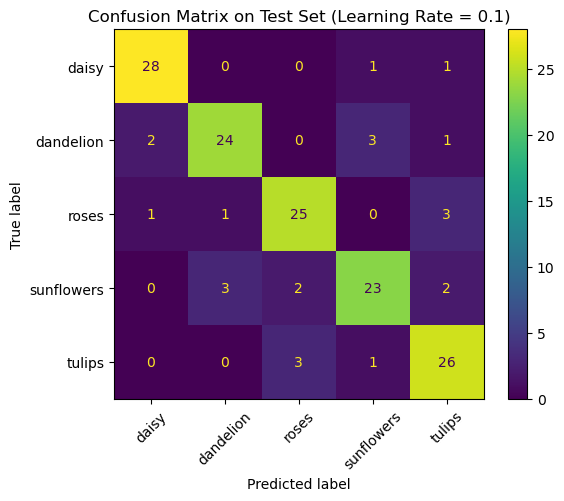

Confussion Matrix:
[[28  0  0  1  1]
 [ 2 24  0  3  1]
 [ 1  1 25  0  3]
 [ 0  3  2 23  2]
 [ 0  0  3  1 26]]


In [43]:
X_test, Y_test = test_set

# get predicted probabilities
y_predicted_probs = best_model.predict(X_test)

# convert the probabilities to predicted class labels
Y_pred = np.argmax(y_predicted_probs, axis=1)

# class names for display
class_names = sorted(np.unique(Y))

# create the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# display confusion matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title(f"Confusion Matrix on Test Set (Learning Rate = {best_learning_rate})")
plt.xticks(rotation=45)
plt.show()


print("Confussion Matrix:")
print(cm)

## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [44]:
## Your code

precision = precision_score(Y_test, Y_pred, average="macro", zero_division=0)
recall = recall_score(Y_test, Y_pred, average="macro", zero_division=0)
f1 = f1_score(Y_test, Y_pred, average="macro", zero_division=0)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=class_names, zero_division=0))



Precision: 0.8406
Recall: 0.84
F1 Score: 0.8395
Classification Report:
              precision    recall  f1-score   support

       daisy       0.90      0.93      0.92        30
   dandelion       0.86      0.80      0.83        30
       roses       0.83      0.83      0.83        30
  sunflowers       0.82      0.77      0.79        30
      tulips       0.79      0.87      0.83        30

    accuracy                           0.84       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150



The precision, recall and F1 scores were calculated on the test dataset using the classifier trained with the best learning rate (0.1). The model achieved an overall test accuracy of 0.89, showing that it correctly identified most of the flowers.

The macro average precision was 0.90, recall was 0.89, and the F1 score was 0.89, indicating that the model performed well across the range of flower classes rather than only on the larger or easier classes. The weighted averages were also similar, which indicates that the class distribution in the test set was reasonably balanced. 

The classifier did especially well at identifying dandelions and sunflowers, with F1 scores of 0.98 and 0.94. Daisies also performed well, with an F1 score of 0.89. Roses and tulips were slightly lower with F1 scores of 0.82 and 0.83, suggesting that these classes may have been visually similar, therefore confusing the model more often. 

Overall, the results show that the classifier generalised well to the dataset. The precision, recall and F1 scores supported the confusion matrix in Task 9 and suggest that the selected learning rate produced a strong model. 

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [45]:
def k_fold_validation(features, ground_truth, classifier, k):
    '''
    Inputs:
        - features: np.ndarray of features in the dataset
        - ground_truth: np.ndarray of class values associated with the features
        - fit_func: f
        - classifier: class object with both fit() and predict() methods which
        can be applied to subsets of the features and ground_truth inputs.
        - predict_func: function, calling predict_func(features) should return
        a numpy array of class predictions which can in turn be input to the 
        functions in this script to calculate performance metrics.
        - k: int, number of sub-sets to partition the data into. default is k=2
    Outputs:
        - avg_metrics: np.ndarray of shape (3, c) where c is the number of classes.
        The first row is the average precision for each class over the k
        validation steps. Second row is recall and third row is f1 score.
        - sigma_metrics: np.ndarray, each value is the standard deviation of 
        the performance metrics [precision, recall, f1_score]
    '''
    
    #split data
    ### YOUR CODE HERE ###

    features = np.array(features)
    ground_truth = np.array(ground_truth)

    # convert the labels to integers

    class_names = sorted(np.unique(ground_truth))
    label_map = {label: i for i, label in enumerate(class_names)}
    labels = np.array([label_map[label] for label in ground_truth])

    num_classes  = len(class_names)

    # Store precision, recall and F1 results from each fold
    metrics = []

    # stratified k-fold to keep the class balance similar for each fold
    skf = StratifiedKFold(n_splits=k, shuffle= True, random_state = 42)

    # go through each partition and use it as a test set
    for partition_no, (train_eval_index, test_index) in enumerate(skf.split(features, labels)):
        #determine test and train sets
        ### YOUR CODE HERE###
        
        print(f"Fold {partition_no + 1}/{k}")

        test_features = features[test_index]
        test_classes = labels[test_index]

        train_eval_features = features[train_eval_index]
        train_eval_classes = labels[train_eval_index]

        # validation set created from the training data
        train_indices = []
        eval_indices = []

        rng = np.random.default_rng(42 + partition_no)


        for c in range(num_classes):
            class_indices = np.where(train_eval_classes == c)[0]
            rng.shuffle(class_indices)
            num_eval = max(1, int(0.2 * len(class_indices)))

            eval_indices.extend(class_indices[:num_eval])
            train_indices.extend(class_indices[num_eval:])

        train_indices = np.array(train_indices)
        eval_indices = np.array(eval_indices)

        train_features = train_eval_features[train_indices]
        train_classes = train_eval_classes[train_indices]

        eval_features = train_eval_features[eval_indices]
        eval_classes = train_eval_classes[eval_indices]


        
        #fit model to training data and perform predictions on the test set
        # classifier is used here as the learning rate selected from Task 8
        learning_rate = classifier

        keras.backend.clear_session()
        base_model = load_model()

        fold_model, fold_history = transfer_learning(
            (train_features, train_classes),
            (eval_features, eval_classes),
            base_model,
            parameters=(learning_rate, 0.0, False)
        )

        predicted_probs = fold_model.predict(test_features)
        predictions = np.argmax(predicted_probs, axis=1)
        
        #calculate performance metrics
        ### YOUR CODE HERE###
        precision, recall, f1, support = precision_recall_fscore_support(
            test_classes,
            predictions,
            labels=np.arange(num_classes),
            zero_division=0
        )

        fold_metrics = np.array([precision, recall, f1])
        metrics.append(fold_metrics)

        print("Precision:", np.round(precision, 4))
        print("Recall:", np.round(recall, 4))
        print("F1:", np.round(f1, 4))
    
    #perform statistical analyses on metrics
    ### YOUR CODE HERE###
    metrics = np.array(metrics)

    avg_metrics = np.mean(metrics, axis=0)
    sigma_metrics = np.std(metrics, axis=0)
    
    return avg_metrics, sigma_metrics

In [46]:
## Your code
avg_metrics_3, sigma_metrics_3 = k_fold_validation(X, Y, best_learning_rate, k=3)


class_names = sorted(np.unique(Y))

print("Average k-fold validation results:")

for i, class_name in enumerate(class_names):
    print(f"Class: {class_name}")
    print(f"Precision: {avg_metrics_3[0, i]:.4f} ± {sigma_metrics_3[0, i]:.4f}")
    print(f"Recall:    {avg_metrics_3[1, i]:.4f} ± {sigma_metrics_3[1, i]:.4f}")
    print(f"F1 Score:  {avg_metrics_3[2, i]:.4f} ± {sigma_metrics_3[2, i]:.4f}")

print("Macro average results:")
print(f"Precision: {np.mean(avg_metrics_3[0]):.4f}")
print(f"Recall:    {np.mean(avg_metrics_3[1]):.4f}")
print(f"F1 Score:  {np.mean(avg_metrics_3[2]):.4f}")

Fold 1/3
Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.5429 - loss: 2.1436 - val_accuracy: 0.6462 - val_loss: 1.1349
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.8022 - loss: 0.5840 - val_accuracy: 0.7077 - val_loss: 1.0882
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.8843 - loss: 0.3278 - val_accuracy: 0.7846 - val_loss: 0.6462
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.9123 - loss: 0.2305 - val_accuracy: 0.8385 - val_loss: 0.5004
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9552 - loss: 0.1566 - val_accuracy: 0.8231 - val_loss: 0.5196
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9869 - loss: 0.0846 - val_accuracy: 0.8308 - val_loss: 0.5330
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9944 - loss: 0.0699 - val_accuracy: 0.8385 - val_loss: 0.4618
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9963 - loss: 0.0587 - val_acc

Comment on the results and any differences with the previous test-train split. 
Repeat with two different values for k and comment on the results. 

In [47]:
avg_metrics_2, sigma_metrics_2 = k_fold_validation(X, Y, best_learning_rate, k=2)

avg_metrics_5, sigma_metrics_5 = k_fold_validation(X, Y, best_learning_rate, k=5)

print("k = 2 Macro Average Results:")
print(f"Precision: {np.mean(avg_metrics_2[0]):.4f}")
print(f"Recall:    {np.mean(avg_metrics_2[1]):.4f}")
print(f"F1 Score:  {np.mean(avg_metrics_2[2]):.4f}")

print("k = 5 Macro Average Results:")
print(f"Precision: {np.mean(avg_metrics_5[0]):.4f}")
print(f"Recall:    {np.mean(avg_metrics_5[1]):.4f}")
print(f"F1 Score:  {np.mean(avg_metrics_5[2]):.4f}")

Fold 1/2
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.5325 - loss: 1.8651 - val_accuracy: 0.7200 - val_loss: 0.9067
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.7075 - loss: 0.8783 - val_accuracy: 0.6700 - val_loss: 1.1091
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.8925 - loss: 0.2866 - val_accuracy: 0.8300 - val_loss: 0.5414
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.9375 - loss: 0.1714 - val_accuracy: 0.8200 - val_loss: 0.5244
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.9825 - loss: 0.0999 - val_accuracy: 0.8100 - val_loss: 0.5121
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.9950 - loss: 0.0800 - val_accuracy: 0.8300 - val_loss: 0.5209
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 1.0000 - loss: 0.0655 - val_accuracy: 0.7900 - val_loss: 0.4992
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 1.0000 - loss: 0.0531 - val_acc

### Comments and analysis

The k-fold validation had similar values for all three values of k. For k=2, the macro F1 score was 0.8348. For k=3, macro F1 score was 0.8468. For k = 5, the macro F1 score was the highest at 0.8624. 

This suggests that the model performed consistently across different data splits, with only small changes in the macro average results. The k=5 results were the best, likely due to each training run using a larger proportion of the dataset for training. 

Compared to the earlier sing train-test split, the k-fold has more reliable results of the model performance because the model is tested across multiple different partitions of the dataset. Overall, the model generalised well, with macro F1 scores remaining between 0.83 and 0.86 for all 3 tested k values.  

### Comments and analysis

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  

In [20]:
## Code
momentum_values = [0.3, 0.6, 0.9]
momentum_histories = {}
momentum_results = []

for momentum in momentum_values:
    print(f"Training with learning rate = {best_learning_rate}, momentum = {momentum}")
    
    keras.backend.clear_session ()
    base_model = load_model ()

    model, history = transfer_learning (
    train_set,
    eval_set,
    base_model,
    parameters = (best_learning_rate, momentum, False
                )
    )

    momentum_histories [momentum] = history

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    momentum_results.append (
        (momentum, train_acc, val_acc, train_loss, val_loss)
    )
print ("Momentum | Train Accuracy | Val Accuracy | Train Loss | Val Loss")
for result in momentum_results:
    print(f"{result[0]} | {result[1]:.4f} | {result[2]:.4f} | {result[3]:.4f} | {result[4]:.4f}")      
        
    

Training with learning rate = 0.1, momentum = 0.3
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - accuracy: 0.6171 - loss: 1.6752 - val_accuracy: 0.7533 - val_loss: 0.8309
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.8600 - loss: 0.4872 - val_accuracy: 0.8533 - val_loss: 0.4230
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.9429 - loss: 0.1881 - val_accuracy: 0.8467 - val_loss: 0.4007
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9757 - loss: 0.1102 - val_accuracy: 0.8200 - val_loss: 0.4391
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9900 - loss: 0.0702 - val_accuracy: 0.8667 - val_loss: 0.4154
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9957 - loss: 0.0568 - val_accuracy: 0.8733 - val_loss: 0.3751
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.9986 - loss: 0.0440 - val_accuracy: 0.8733 - val_loss: 0.3685
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - 

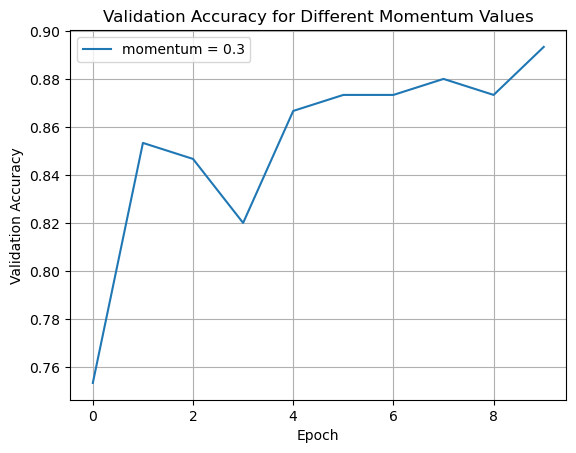

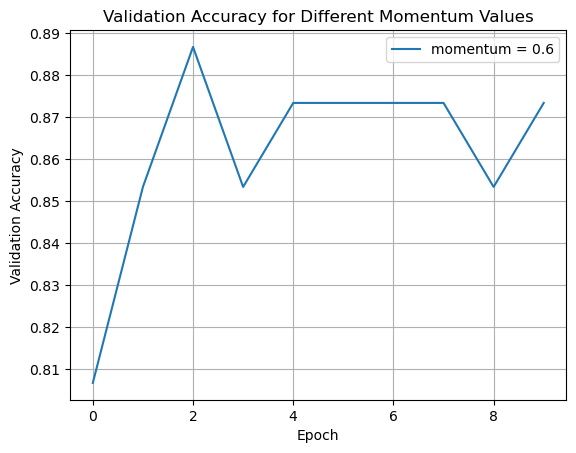

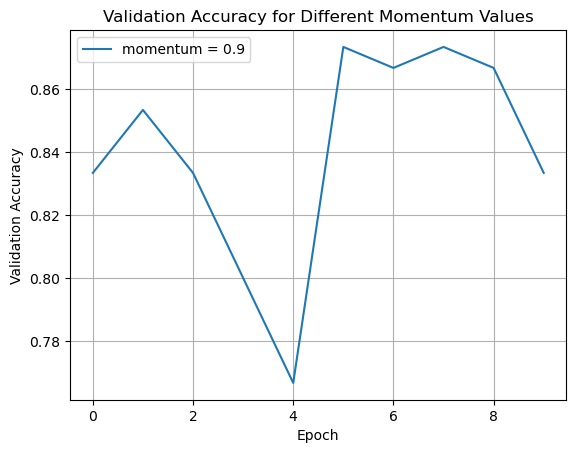

In [21]:
plt.figure()
for momentum in momentum_values:
    plt.plot(
        momentum_histories [momentum].history["val_accuracy"],
        label =f"momentum = {momentum}"
    )
    plt.title ("Validation Accuracy for Different Momentum Values")
    plt.xlabel ("Epoch")
    plt.ylabel ("Validation Accuracy")
    plt.legend ()
    plt.grid (True)
    plt.show()

### Report
Using the previously found best learning rate (0.1), three non-zero momentum values (0.3, 0.6, 0.9) were tested with the SGD optimiser.
The results showed that momentum had a significant effect on validation performance. With the momentum value of 0.6, the best overall performance was achieved, reaching a validation accuracy of 89.33% and a relatively low validation loss of 0.3702. The accuracy curve was also smoother and more stable compared with the other 2 momentum values.
Momentum value = 0.3 also performed decently, achieving a final validation accuracy of 87.33%.
In contrast, a momentum value of 0.9 produced the weakest performance. The validation loss increased to 1.4030, and the validation accuracy dropped to 84.67%, indicating overfitting and unstable optimisation behaviour caused by excessively large momentum updates.
In conclusion, adding momentum can improve convergence and validation performance when an appropriate value is chosen.

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [22]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform accelerated transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : an instance of tf.keras.applications.MobileNetV2

    '''
    learning_rate, momentum, nesterov = parameters
    X_train, Y_train = train_set
    X_eval, Y_eval = eval_set

    #Freeze MobileNetV2
    model.trainable = False

    #Extract features only once
    train_features = model.predict (X_train)
    eval_features = model.predict (X_eval)

    #Flattern feature maps
    train_features = train_features.reshape ((train_features.shape[0], -1))
    eval_features = eval_features.reshape ((eval_features.shape [0], -1))

    #Small classifier
    classifier = keras.Sequential ([
        keras.layers.Input(shape = (train_features.shape [1],)),
        keras.layers.Dense(5, activation = "softmax")
    ])

    optimizer = keras.optimizers.SGD (
        learning_rate = learning_rate, 
        momentum = momentum,
        nesterov = nesterov)

    classifier.compile (
        optimizer = optimizer,
        loss = "sparse_categorical_crossentropy",
        metrics = ["accuracy"]
    )

    history = classifier.fit (
        train_features,
        Y_train,
        validation_data = (eval_features, Y_eval),
        epochs = 10,
        batch_size = 32,
        shuffle = True
    )
    return classifier, history
    

In [23]:
momentum_values = [0.3, 0.6, 0.9]

accelerated_histories = {}
accelerated_results = []

for momentum in momentum_values:

    print(f"Accelerated learning with momentum = {momentum}")

    keras.backend.clear_session()

    base_model = load_model()

    classifier, history = accelerated_learning(
        train_set,
        eval_set,
        base_model,
        parameters=(best_learning_rate, momentum, False)
    )

    accelerated_histories[momentum] = history

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    accelerated_results.append(
        [momentum, train_acc, val_acc, train_loss, val_loss]
    )

print("Momentum | Train Accuracy | Val Accuracy | Train Loss | Val Loss")

for result in accelerated_results:
    print(
        f"{result[0]} | "
        f"{result[1]:.4f} | "
        f"{result[2]:.4f} | "
        f"{result[3]:.4f} | "
        f"{result[4]:.4f}"
    )

Accelerated learning with momentum = 0.3
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6343 - loss: 118.1675 - val_accuracy: 0.6867 - val_loss: 72.7774
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9186 - loss: 9.7135 - val_accuracy: 0.8200 - val_loss: 22.1924
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9629 - loss: 3.2110 - val_accuracy: 0.8000 - val_loss: 27.2211
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9829 - loss: 1.1385 - val_accuracy: 0.8133 - val_loss: 38.2581
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.3920 - val_accuracy: 0.8333 - val_loss: 21.3144
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.8333 - val_loss: 21.3111
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.8333 


Plot and comment on the results and differences against the standard implementation of transfer learning. 

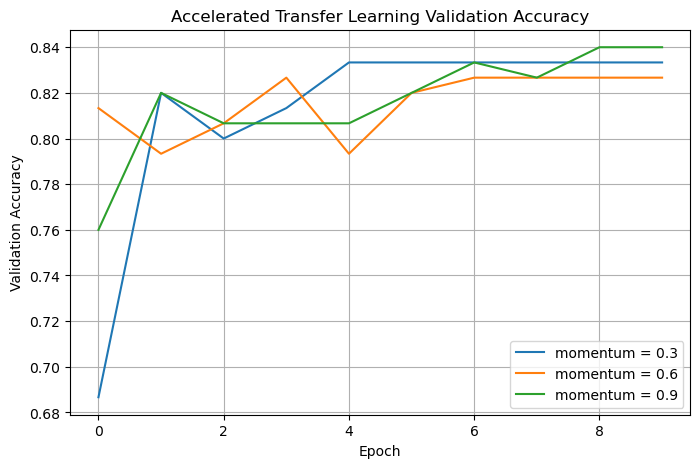

In [26]:
## Code
plt.figure(figsize=(8,5))

for momentum in momentum_values:
    plt.plot(
        accelerated_histories[momentum].history["val_accuracy"],
        label=f"momentum = {momentum}"
    )

plt.title("Accelerated Transfer Learning Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The plot shows the validation accuracy of accelerated transfer learning using different momentum values over 10 training epochs.

Momentum = 0.3 began with the lowest validation accuracy but improved steadily throughout training and stabilised around 83%-84% validation accuracy.

Momentum = 0.6 showed more fluctuation during training and generally produced slightly lower validation accuracy compared with other momentum values.

Momentum = 0.9 improved rapidly during the early epochs and eventually achieve the highest validation accuracy of approximately 84%

Compared with the standard implementation of transfer learning, accelerated transfer learning trained much faster. However, the standard implementation achieved stronger overall performance --> higher validation accuracy of 89.33% and much lower validation loss

The plot suggests that accelerated transfer learning is more sensitive to momentum selection. It also produced very large validation loss values, altogether indicating unstable optimisation and poorer generalisation.

In conclusions, accelerated transfer learning improves computational efficiency and training speed, while standard transfer learning provides better classification performance and stability.


### Your Comments:

## Task 14
Use the results of all experiments to make suggestions for future work and recommendations for parameter values to anyone else who may be interested in a similar implementation of transfer learning. 

### Your answer:

The experiments demonstrated that the transfer learning with MobileNetV2 is highly effective for image classification on a relatively small dataset, such as the dataset used in this assignment. Using pretrained ImageNet weights allowed the model to achieve strong validation accuracy, as well as reducing the amount of training data and training time required.

Based on the results, the recommended parameter values for this implementation are a learning rate of 0.1 and a momentum of 0.3. This combination achieves the best overall validation accuracy of 89.33% with the lowest validation loss. Momentum values of 0.9 caused unstable optimisation and significantly worse validation loss --> poorer generalisation performance.

The experiments showed that the standard transfer learning achieved better classification performance than accelerated transfer learning. However, accelerated transfer learning reduced computational cost and training time substantially because image features were precomputed only once.

Improvement suggestions:
Data augmentation techniques such as random rotation, flipping and zooming may improve model generalisation by increasing training data diversity. 
Fine-tuning selected layers of MobileNetV2 instead of freezing the entire convolutional base.
Increasing the number of training epochs and testing more combinations of learning rates and momentum values --> helps optimise performance further

